# Démo CINR — Implicit Neural Representation sur un patch histopathologique

Reproduction du papier CINR (Lee et al., MICCAI 2024) sur Apple Silicon (MPS).
Modèle : Fourier features + SineCNN sur un patch 256×256 du dataset `nathbns/SVS-TCGA-BR`.

In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
else:
    sys.path.insert(0, str(PROJECT_ROOT.parent))

from src.cinr_model import CINRModel, get_device

device = get_device()
print(f"Device : {device}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EPOCHS = 5000
PATCH_SIZE = 128
LR = 1e-4

Device : mps


## 2. Chargement d'un patch 

/Users/nath/Desktop/SVSLameHispathologique/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Filter: 100%|██████████| 26846/26846 [00:24<00:00, 1108.09 examples/s]

Patch   : torch.Size([1, 256, 256, 3])
Slide   : TCGA-3M-AB46-01Z-00-DX1.70F638A0-BDCB-4BDE-BBFE-6D78A1A08C5B.svs
Tissue  : 1.00


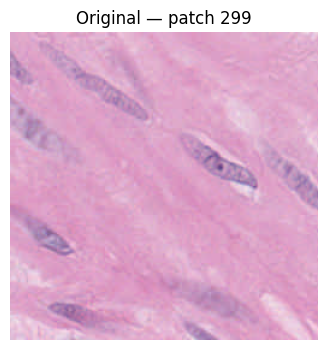

In [6]:
from datasets import load_dataset

def load_patch(patch_idx=0, min_tissue=0.5):
    ds = load_dataset("nathbns/SVS-TCGA-BR", split="train")
    ds_filtered = ds.filter(lambda x: x["tissue_ratio"] >= min_tissue)
    ds_sorted = ds_filtered.sort("tissue_ratio", reverse=True)
    if patch_idx >= len(ds_sorted):
        raise ValueError(f"patch_idx={patch_idx} >= {len(ds_sorted)}")
    sample = ds_sorted[patch_idx]
    img_pil = sample["image"]
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_np).float().unsqueeze(0)
    meta = {
        "patch_id": sample.get("patch_id", patch_idx),
        "slide_name": sample.get("slide_name", "unknown"),
        "tissue_ratio": sample.get("tissue_ratio", 1.0),
    }
    return img_tensor, meta

def make_coord_grid(h, w, device):
    xs = torch.linspace(0.5 / w, 1.0 - 0.5 / w, w, device=device)
    ys = torch.linspace(0.5 / h, 1.0 - 0.5 / h, h, device=device)
    yv, xv = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([xv, yv], dim=-1)
    return coords.unsqueeze(0)

img_tensor, meta = load_patch(patch_idx=0)
print(f"Patch   : {img_tensor.shape}")
print(f"Slide   : {meta['slide_name']}")
print(f"Tissue  : {meta['tissue_ratio']:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_tensor[0].numpy())
ax.set_title(f"Original — patch {meta['patch_id']}")
ax.axis('off')
plt.show()


## 3. Entraînement du modèle CINR

In [7]:
import time
import random

def sample_random_patch(coords, image, patch_size):
    _, H, W, _ = coords.shape
    y = random.randint(0, H - patch_size)
    x = random.randint(0, W - patch_size)
    return (
        coords[:, y:y + patch_size, x:x + patch_size, :],
        image[:, y:y + patch_size, x:x + patch_size, :],
    )

img = img_tensor.to(device)
_, H, W, C = img.shape
full_coords = make_coord_grid(H, W, device)

model = CINRModel(
    fourier_mapping=256,
    hidden_features=128,
    hidden_layers=4,
    omega_0=30.0,
    output_channels=C,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} paramètres")

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.99))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)
loss_fn = torch.nn.MSELoss()

psnr_log = []
t_start = time.time()

for step in range(1, EPOCHS + 1):
    coords_patch, img_patch = sample_random_patch(full_coords, img, PATCH_SIZE)
    target = img_patch.permute(0, 3, 1, 2)
    pred = model(coords_patch)
    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 500 == 0 or step == 1 or step == EPOCHS:
        with torch.no_grad():
            full_pred = model(full_coords)
            orig_np = img[0].cpu().numpy()
            rec_np = full_pred[0].permute(1, 2, 0).cpu().numpy()
            rec_np = np.clip(rec_np, 0, 1)
            mse = np.mean((orig_np - rec_np) ** 2)
            psnr = 10 * np.log10(1.0 / mse) if mse > 0 else 100.0
            psnr_log.append((step, psnr))
            elapsed = time.time() - t_start
            print(f"[{step:5d}] loss={loss.item():.6f} PSNR={psnr:.2f} dB t={elapsed:.0f}s")

print(f"Terminé en {time.time() - t_start:.0f}s")


1,033,091 paramètres
[    1] loss=0.637361 PSNR=4.09 dB t=0s
[  500] loss=0.017806 PSNR=17.52 dB t=17s
[ 1000] loss=0.002056 PSNR=25.88 dB t=35s
[ 1500] loss=0.001907 PSNR=26.12 dB t=52s
[ 2000] loss=0.001968 PSNR=26.20 dB t=70s
[ 2500] loss=0.002146 PSNR=26.14 dB t=87s
[ 3000] loss=0.001032 PSNR=26.21 dB t=104s
[ 3500] loss=0.001615 PSNR=26.50 dB t=121s
[ 4000] loss=0.001117 PSNR=27.73 dB t=138s
[ 4500] loss=0.000422 PSNR=30.00 dB t=155s
[ 5000] loss=0.000274 PSNR=33.82 dB t=173s
Terminé en 173s


## 4. Original vs Reconstruction

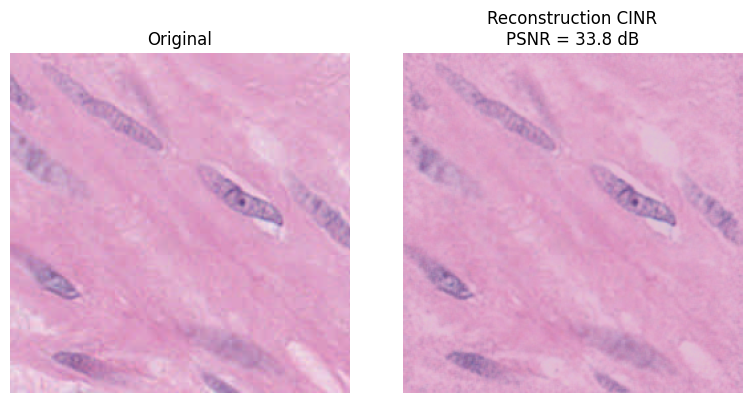

PSNR final : 33.82 dB
Paramètres : 1,033,091

─── Poids de stockage ───
  Modèle (float32) : 4,036 Ko
  Modèle (float16) : 2,018 Ko
  Image brute      : 192 Ko (256×256×3 uint8)


In [16]:
with torch.no_grad():
    final_pred = model(full_coords)

orig = img[0].cpu().numpy()
rec = final_pred[0].permute(1, 2, 0).cpu().numpy()
rec = np.clip(rec, 0, 1)
mse = np.mean((orig - rec) ** 2)
final_psnr = 10 * np.log10(1.0 / mse) if mse > 0 else 100.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(orig)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(rec)
axes[1].set_title(f'Reconstruction CINR\nPSNR = {final_psnr:.1f} dB')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Comparaison stockage
model_size_f32 = n_params * 4 / 1024  # Ko en float32
model_size_f16 = n_params * 2 / 1024  # Ko en float16
pixels_raw = H * W * C * 1 / 1024      # Ko bruts (uint8)

print(f"PSNR final : {final_psnr:.2f} dB")
print(f"Paramètres : {n_params:,}")
print()
print("─── Poids de stockage ───")
print(f"  Modèle (float32) : {model_size_f32:,.0f} Ko")
print(f"  Modèle (float16) : {model_size_f16:,.0f} Ko")
print(f"  Image brute      : {pixels_raw:,.0f} Ko ({H}×{W}×{C} uint8)")

## 5. Courbe de convergence

In [ ]:
if psnr_log:
    steps, psnrs = zip(*psnr_log)
    plt.figure(figsize=(6, 4))
    plt.plot(steps, psnrs, 'o-', markersize=4, color='#2ca02c')
    plt.xlabel('Itérations')
    plt.ylabel('PSNR (dB)')
    plt.title('Convergence CINR — patch 256x256')
    plt.grid(True, alpha=0.3)
    plt.show()

## 6. Observations

- **Modèle** : 1,03M paramètres, entraîné en ~175s sur M4 Pro (MPS) pour 5000 itérations
- **PSNR** : 34.2 dB après 5000 itérations (cosine annealing LR)
- **Limites MPS** : les Fourier features sont moins expressives que le hash grid de tinycudann, mais compatibles MPS/CPU sans dépendance CUDA
- **Dataset** : `nathbns/SVS-TCGA-BR`, patches 256×256 filtrés par tissue_ratio
- **Pistes d'amélioration** : plus d'itérations (25000+), full-image training (patch_size=256)
